# Time-index rounding in PyCBC's CPU chi-square calculation

PyCBC's signal-consistency chi-square compares a candidate gravitational-wave signal across frequency bins. Its CPU calculation uses
\[
q_b(t)=\sum_{k\in b}c_k e^{2\pi i kt/N},\qquad S(t)=\sum_b|q_b(t)|^2,
\qquad \chi^2=(pS-|z|^2)A^2.
\]
Here $c_k$ is the correlation spectrum, $N$ its length, $t$ a sample index **within the segment**, $p$ the bin count, $z$ the unnormalized SNR and $A$ its normalization.

The [original implementation](https://github.com/gwastro/pycbc/blob/454ee900e/pycbc/vetoes/chisq_cpu.pyx) converts $t$ to float32 for complex64 input. Some integers above $2^{24}$ then become neighbouring indices. This notebook isolates that conversion and compares the actual compiled kernel with a patch that keeps shifts in float64. Correlation storage, internal arithmetic, and output dtype otherwise stay unchanged; fractional shifts remain supported.

## Setup

Run alongside `cpu_chisq_review.py` and the archived `kernels/upstream.pyx` and `kernels/shifts.pyx` sources, with PyCBC, NumPy, Matplotlib, Cython and a C++ compiler available. The helper builds and caches the kernels; no FFT is used in this calculation.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Wswiglal-redir-stdio:")

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from pycbc.types import Array
from cpu_chisq_review import kernels, load_capture, plot_style

plot_style()
cpu = kernels(('upstream', 'shifts'))

print("CPU source: gwastro/pycbc@454ee900e (2026-09-22 upstream snapshot)")

Compiling archived CPU kernels once; build log: /var/folders/l0/3dr1pyw15ln58b6xh74j_41w0000gn/T/pycbc-chisq-review-4a45bb4dd1942f62/build.log


CPU source: gwastro/pycbc@454ee900e (2026-09-22 upstream snapshot)


## A two-frequency example

Choose $N=2^{25}$, a bin containing only $c_0=c_1=i$, and indices around $N/2$. Then
\[
S(t)=4\sin^2\!\left[\pi(t-N/2)/N\right].
\]
A broadcast view supplies the logical array length without allocating a large array. Only two frequencies are visited: repeated-rotation drift cannot explain the discrepancy. The kernel still uses a shortened value of $\pi$ and float32 working arithmetic for complex64 input. Those roundoff effects remain, so the check allows a small residual.

In [2]:
length = 2**25
offsets = np.array([-1, 0, 1], dtype=np.int64)
indices = length // 2 + offsets
correlation = Array(np.broadcast_to(np.array([1j], dtype=np.complex64),
                                   (length,)), copy=False)
expected = 4 * np.sin(np.pi * offsets / length)**2
before = cpu["upstream"].shift_sum(correlation, indices, [0, 2])
after = cpu["shifts"].shift_sum(correlation, indices, [0, 2])
np.testing.assert_allclose(after, expected, rtol=0.01, atol=1e-18)
assert before[-1] < expected[-1] / 1000
assert before.dtype == after.dtype == np.dtype(np.float32)

rows = ["| Requested index | Index after float32 cast | Exact S | Original S | Patched S |",
        "|---:|---:|---:|---:|---:|"]
for t, exact, old, new in zip(indices, expected, before, after):
    rows.append(f"| {t} | {int(np.float32(t))} | {exact:.6e} | {old:.6e} | {new:.6e} |")
display(Markdown("\n".join(rows)))


| Requested index | Index after float32 cast | Exact S | Original S | Patched S |
|---:|---:|---:|---:|---:|
| 16777215 | 16777215 | 3.506388e-14 | 3.528511e-14 | 3.528511e-14 |
| 16777216 | 16777216 | 0.000000e+00 | 3.478560e-19 | 3.478560e-19 |
| 16777217 | 16777216 | 3.506388e-14 | 3.478560e-19 | 3.484335e-14 |

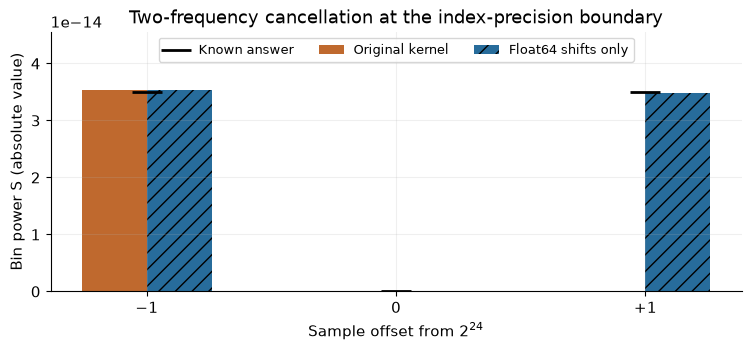

At index 16777217, S changes from **3.478560e-19** to **3.484335e-14**; the known answer is **3.506388e-14**. These powers are tiny: the example establishes coordinate loss, not a typical science-error magnitude.

In [3]:
fig, ax = plt.subplots(figsize=(7.4, 3.4), constrained_layout=True)
width = 0.26
ax.bar(offsets - width / 2, before, width, color="#BF692E",
       label="Original kernel")
ax.bar(offsets + width / 2, after, width, color="#276C9B",
       hatch="//", label="Float64 shifts only")
ax.plot(offsets, expected, "k_", markersize=22, markeredgewidth=2,
        linestyle="none", label="Known answer")
ax.set(xticks=offsets, xticklabels=["−1", "0", "+1"],
       xlabel=r"Sample offset from $2^{24}$",
       ylabel="Bin power S (absolute value)",
       title="Two-frequency cancellation at the index-precision boundary",
       ylim=(0, 1.3 * max(expected)))
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax.legend(loc="upper center", ncol=3, fontsize=9)
plt.show()
display(Markdown(
    f"At index {indices[-1]}, S changes from **{before[-1]:.6e}** to "
    f"**{after[-1]:.6e}**; the known answer is **{expected[-1]:.6e}**. "
    "These powers are tiny: the example establishes coordinate loss, "
    "not a typical science-error magnitude."))


## Does the captured LIGO calculation reach this boundary?

The [saved H1 input and provenance](../data/point-input-05.json) contain three selected points from a 512-second, 2048-Hz CPU search segment. They were selected by their CPU-versus-FFT discrepancy from the first eleven captured points; they are not a representative sample. This check tests whether index conversion changes these inputs or their chi-square values, and shows when longer segments could cross the boundary.

In [4]:
capture = load_capture()
data_indices = np.asarray(capture["indices"])
round_trip = data_indices.astype(np.float32).astype(data_indices.dtype)
np.testing.assert_array_equal(round_trip, data_indices)
data_correlation = Array(capture["corr"], copy=False)
data_before = cpu["upstream"].shift_sum(data_correlation, data_indices,
                                       capture["bins"])
data_after = cpu["shifts"].shift_sum(data_correlation, data_indices,
                                    capture["bins"])
np.testing.assert_array_equal(data_before, data_after)
bin_count = len(capture["bins"]) - 1
snr_power = abs(np.asarray(capture["snr"], dtype=np.complex128))**2
norm = float(capture["norm"])
chisq_before = (bin_count * data_before.astype(np.float64) - snr_power) * norm**2
chisq_after = (bin_count * data_after.astype(np.float64) - snr_power) * norm**2
rows = ["| H1 sample index | Index preserved exactly? | Change in S | Change in chi-square |",
        "|---:|:---:|---:|---:|"]
for t, old, new, old_chi, new_chi in zip(data_indices, data_before, data_after,
                                      chisq_before, chisq_after):
    rows.append(f"| {t} | Yes | {float(new) - float(old):.1e} | {new_chi-old_chi:.1e} |")
display(Markdown("\n".join(rows)))
rows = ["| Sampling rate (Hz) | Time of sample 2²⁴ within segment (seconds) |",
        "|---:|---:|"]
for rate in (2048, 4096, 16384):
    rows.append(f"| {rate} | {2**24 / rate:.0f} |")
display(Markdown("\n".join(rows)))


| H1 sample index | Index preserved exactly? | Change in S | Change in chi-square |
|---:|:---:|---:|---:|
| 484954 | Yes | 0.0e+00 | 0.0e+00 |
| 619888 | Yes | 0.0e+00 | 0.0e+00 |
| 656106 | Yes | 0.0e+00 | 0.0e+00 |

| Sampling rate (Hz) | Time of sample 2²⁴ within segment (seconds) |
|---:|---:|
| 2048 | 8192 |
| 4096 | 4096 |
| 16384 | 1024 |

All integer indices in a transform of length at most $2^{24}$ are safe. The captured data therefore show **no effect from this fix**.

The search supplies sample positions within each FFT segment, adding the cumulative observation offset only after chi-square evaluation. Longer observing runs do not by themselves reach this boundary; a sufficiently long individual segment and an affected trigger position are required.

In a hypothetical longer transform, losing one sample changes the relative phase of frequencies separated by $f_s/4$ by $\pi/2$, where $f_s$ is the sampling rate. Bin powers and chi-square can consequently change. No affected science configuration has been identified here; effects on detection ranking or sensitivity remain unproven.